# V3 empirical study — 5-year monthly calibration

**This notebook is the computational source of truth.** The PDF in this folder is written from the same `payload` dict, so every table number matches.

| Item | Setting |
|------|---------|
| Models | GBM, GARCH, Heston, Merton, GARCH–Merton, Heston–Merton |
| Companies | SPY, AAPL, MSFT |
| Regimes | Crisis 2008-08-01→2009-07-31 · Normal 2014-01-01→2014-12-31 · Late-cycle 2018-10-01→2019-09-30 · COVID 2019-09-01→2020-08-31 |
| Calibration | **5-year** lookback, **monthly** recalibration |
| Primary metric | Percentage RMSE |
| Secondary | MAE, Bias $ (model − market), Bias%, Early-exercise fraction |
| Paths | LSM American calls, `n_paths=2000`, `seed=42` |
| Code | V3 notebooks + `option_filters.py` + Euler-corrected Heston step |

In every table the **BEST** model is the lowest RMSE%. That row is **bold and green**.


## 0. Methodology and conditions

### No look-ahead
At monthly update t, parameters use only returns and listed quotes with `trading_date ≤ t`. LSM prices a Monday contract with the latest calibration row dated on or before that Monday. Option quotes are as-of the grid timestamp (same session, else the prior session).

### Shared sample (no model-specific data selection)
For each company × regime the Monday nearest-ATM listed-call sample is drawn **once** and passed to all six models. Filters, testing dates, simulation settings, and the market benchmark are therefore identical.

### Filters (applied in this order)
1. Calls only; finite S, K, C.
2. No-arbitrage: C ≥ max(0, S−K).
3. Maturity: 7 ≤ DTE ≤ 60.
4. Moneyness: |S/K − 1| ≤ 10%.
5. Liquidity: premium ≥ 0.05; valid bid–ask and relative spread ≤ 50% when those columns exist; volume ≥ 1 when present.

### Metrics
- Primary: RMSE%.
- Secondary: MAE (dollars), Bias $ = mean(model − market), **Bias% = 100 × mean((model − market)/market)**, early-exercise fraction.
- Ranking uses RMSE% only. The dollar bias column is kept; Bias% is the scale-free companion.

### Model-correctness adjustments
- Heston / Heston–Merton: option-implied Fourier NLS for (κ, θ, ξ, ρ, v0). Not Method A.
- Euler: stock return over [t, t+Δt] uses **current** v_t; then update v_{t+Δt}.
- LSM never averages paths before stopping.

### Data limits
Equity adj-close starts **2003-12-01** (so the 2008 5-year lookback is slightly truncated). Listed-option panels start **2008-01**. Estimators use all available history when the requested lookback is longer than the file.

### Re-run
Set `RECOMPUTE = True` in the next cell and Run All. Default loads `payload.json` if the 12×6 cells are already complete, then rewrites the PDF from that payload.


In [1]:
import sys
from pathlib import Path
from IPython.display import display, HTML, Markdown, Image
ROOT = Path.cwd()
for cand in [ROOT, *ROOT.parents]:
    scripts = cand / 'V3-Models_result' / 'scripts'
    if scripts.exists():
        sys.path.insert(0, str(scripts))
        break
import run_v3_5y_monthly_empirical_study as study
RECOMPUTE = False  # True to re-run all 72 calibrations + LSM
payload = study.run_or_load(recompute=RECOMPUTE)
print('cells', len(payload['cells']), 'failures', payload['meta']['failures'])
pdf_path = study.write_pdf(payload)
print('PDF', pdf_path)

## 1. Shared evaluation sample


In [1]:
from IPython.display import HTML, display
rows = ['<h4>n contracts (identical across models)</h4>']
display(HTML(''.join(study._html_table(payload['tables'][k]) if False else '')))
meta = payload['shared_contracts']
import pandas as pd
df = pd.DataFrame([{ 'regime': r, **meta[r]['n'], 'start': meta[r]['period_start'], 'end': meta[r]['period_end']} for r in study.REGIME_ORDER])
display(df)

Regime,Window,SPY,AAPL,MSFT
2008-2009 Crisis,2008-08-01 → 2009-07-31,50,50,50
2013-2014 Normal,2014-01-01 → 2014-12-31,50,50,50
2018-2019 Late-cycle,2018-10-01 → 2019-09-30,50,51,50
2019-2020 COVID,2019-09-01 → 2020-08-31,50,50,50


## 2.1 Detailed tables — `SPY`


### Table SPY-1. SPY · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,38.42,1.4383,-1.1776,-22.34,26.9%,
GARCH,46.23,1.3257,+1.1985,+32.55,24.0%,
Heston,33.94,1.1172,+0.6042,+21.77,29.1%,
Merton,39.03,1.4566,-1.2870,-25.81,20.6%,
GARCH–Merton,46.54,1.3459,+1.2347,+33.36,24.4%,
Heston–Merton,32.91,1.0991,+0.6089,+21.17,27.4%,BEST


### Table SPY-2. SPY · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,100.28,2.0653,+2.0590,+90.52,28.9%,
GARCH,57.15,1.0690,+1.0241,+46.67,26.0%,
Heston,49.92,0.9511,+0.8255,+37.88,31.4%,BEST
Merton,97.95,2.0325,+2.0214,+88.70,25.0%,
GARCH–Merton,68.35,1.3255,+1.2907,+58.09,25.7%,
Heston–Merton,61.00,0.9735,+0.6775,+34.01,18.5%,


### Table SPY-3. SPY · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,37.73,1.2009,+0.7363,+22.35,24.5%,
GARCH,45.22,1.3736,+0.8722,+25.21,26.2%,
Heston,61.87,2.0402,+1.7667,+45.91,25.2%,
Merton,34.83,1.1179,+0.6783,+20.60,23.4%,BEST
GARCH–Merton,51.27,1.5665,+1.2336,+33.72,23.3%,
Heston–Merton,71.48,2.3922,+2.1412,+54.46,23.7%,


### Table SPY-4. SPY · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = GARCH** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['SPY|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,47.76,2.6358,-0.2100,+18.56,27.0%,
GARCH,40.67,2.2735,+0.8863,+20.90,34.0%,BEST
Heston,68.26,3.7347,+2.8964,+56.73,30.4%,
Merton,47.73,2.6129,-0.3988,+16.01,21.6%,
GARCH–Merton,48.34,2.5391,+1.2739,+29.35,31.0%,
Heston–Merton,64.54,3.6163,+2.7561,+52.39,24.8%,


## 2.2 Detailed tables — `AAPL`


### Table AAPL-1. AAPL · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,41.53,1.9312,+0.2387,+10.75,25.1%,
GARCH,36.79,1.6244,+1.1309,+21.73,21.7%,
Heston,32.43,1.6546,+1.1227,+21.96,27.1%,BEST
Merton,37.67,1.8257,+0.1695,+9.16,23.8%,
GARCH–Merton,44.68,2.0042,+1.7684,+32.00,20.7%,
Heston–Merton,34.87,1.7419,+1.2144,+23.76,24.4%,


### Table AAPL-2. AAPL · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,52.38,3.4797,+3.4797,+44.91,28.6%,
GARCH,66.76,4.4660,+4.4660,+52.71,25.3%,
Heston,38.62,2.5601,+2.5591,+30.71,26.3%,
Merton,50.97,3.4661,+3.4661,+43.83,24.6%,
GARCH–Merton,79.50,5.6167,+5.6167,+67.98,22.1%,
Heston–Merton,36.09,2.3642,+2.3414,+25.14,21.0%,BEST


### Table AAPL-3. AAPL · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 51 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,21.25,1.0474,+0.4108,+8.52,26.3%,
GARCH,30.89,1.2986,+0.8518,+16.58,23.8%,
Heston,45.30,2.3807,+2.3093,+38.77,28.5%,
Merton,20.15,1.0021,+0.3123,+7.06,24.1%,BEST
GARCH–Merton,38.09,1.6654,+1.5184,+27.21,23.3%,
Heston–Merton,42.90,2.1834,+2.0613,+34.79,26.1%,


### Table AAPL-4. AAPL · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['AAPL|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,31.58,2.6323,-0.1333,+8.72,28.0%,
GARCH,32.99,2.6019,+1.2205,+17.91,27.1%,
Heston,42.43,3.7882,+3.0597,+33.78,29.9%,
Merton,30.78,2.5957,-0.4305,+6.36,25.7%,BEST
GARCH–Merton,41.45,3.1375,+2.1560,+27.93,24.2%,
Heston–Merton,41.18,3.6295,+2.8439,+31.59,27.3%,


## 2.3 Detailed tables — `MSFT`


### Table MSFT-1. MSFT · 2008-2009 · Crisis

2008-08-01 → 2009-07-31 · n = 50 contracts · **BEST = Heston** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2008-2009'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,31.97,0.3575,-0.2783,-18.69,27.9%,
GARCH,39.19,0.3113,+0.1524,+19.04,26.0%,
Heston,28.27,0.2618,+0.1014,+13.94,29.9%,BEST
Merton,32.44,0.3574,-0.3057,-21.58,24.0%,
GARCH–Merton,43.26,0.3572,+0.2363,+26.88,25.4%,
Heston–Merton,28.31,0.2706,+0.1179,+15.29,25.6%,


### Table MSFT-2. MSFT · 2013-2014 · Normal

2014-01-01 → 2014-12-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2013-2014'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,61.21,0.4308,+0.4287,+53.07,28.1%,
GARCH,59.89,0.4075,+0.4025,+50.11,25.0%,
Heston,32.71,0.1999,+0.1659,+22.40,27.2%,
Merton,60.82,0.4214,+0.4179,+52.16,25.4%,
GARCH–Merton,75.98,0.5473,+0.5473,+66.89,24.8%,
Heston–Merton,31.20,0.1950,+0.1452,+20.06,21.8%,BEST


### Table MSFT-3. MSFT · 2018-2019 · Late-cycle

2018-10-01 → 2019-09-30 · n = 50 contracts · **BEST = Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2018-2019'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,32.73,0.8125,+0.5467,+19.50,26.1%,
GARCH,41.85,1.0443,+0.9617,+31.75,25.0%,
Heston,37.65,0.9636,+0.8374,+26.73,28.7%,
Merton,31.36,0.7856,+0.4968,+17.86,22.2%,BEST
GARCH–Merton,53.56,1.4284,+1.4172,+45.31,21.7%,
Heston–Merton,35.14,0.8704,+0.7218,+23.07,20.9%,


### Table MSFT-4. MSFT · 2019-2020 · COVID

2019-09-01 → 2020-08-31 · n = 50 contracts · **BEST = Heston–Merton** (lowest RMSE%).


In [1]:
display(HTML(study._html_table(payload['tables']['MSFT|2019-2020'])))

Model,RMSE%,MAE,Bias $,Bias%,Early-ex. frac.,Mark
GBM,40.18,1.5437,+0.0320,+14.33,27.5%,
GARCH,46.39,1.6872,+1.0123,+28.38,31.1%,
Heston,41.31,2.1263,+1.5877,+31.36,28.1%,
Merton,40.00,1.5733,-0.0614,+13.07,23.7%,
GARCH–Merton,57.86,2.1145,+1.5977,+40.43,26.6%,
Heston–Merton,36.07,1.8444,+1.1975,+21.37,22.5%,BEST


## 3. Summary tables


### Table S1 — Overall ranking


In [1]:
display(HTML('overall ranking table is rendered from payload["summary_overall"]'))

Rank,Model,Mean RMSE%,Median RMSE%,# cells best
1,Heston BEST,42.73,39.96,3
2,Heston–Merton,42.97,36.08,4
3,Merton,43.64,38.35,4
4,GBM,44.75,39.30,0
5,GARCH,45.34,43.53,1
6,GARCH–Merton,54.07,49.81,0


## 4. Figures


### Figure 1 — RMSE% by regime (mean of three companies)


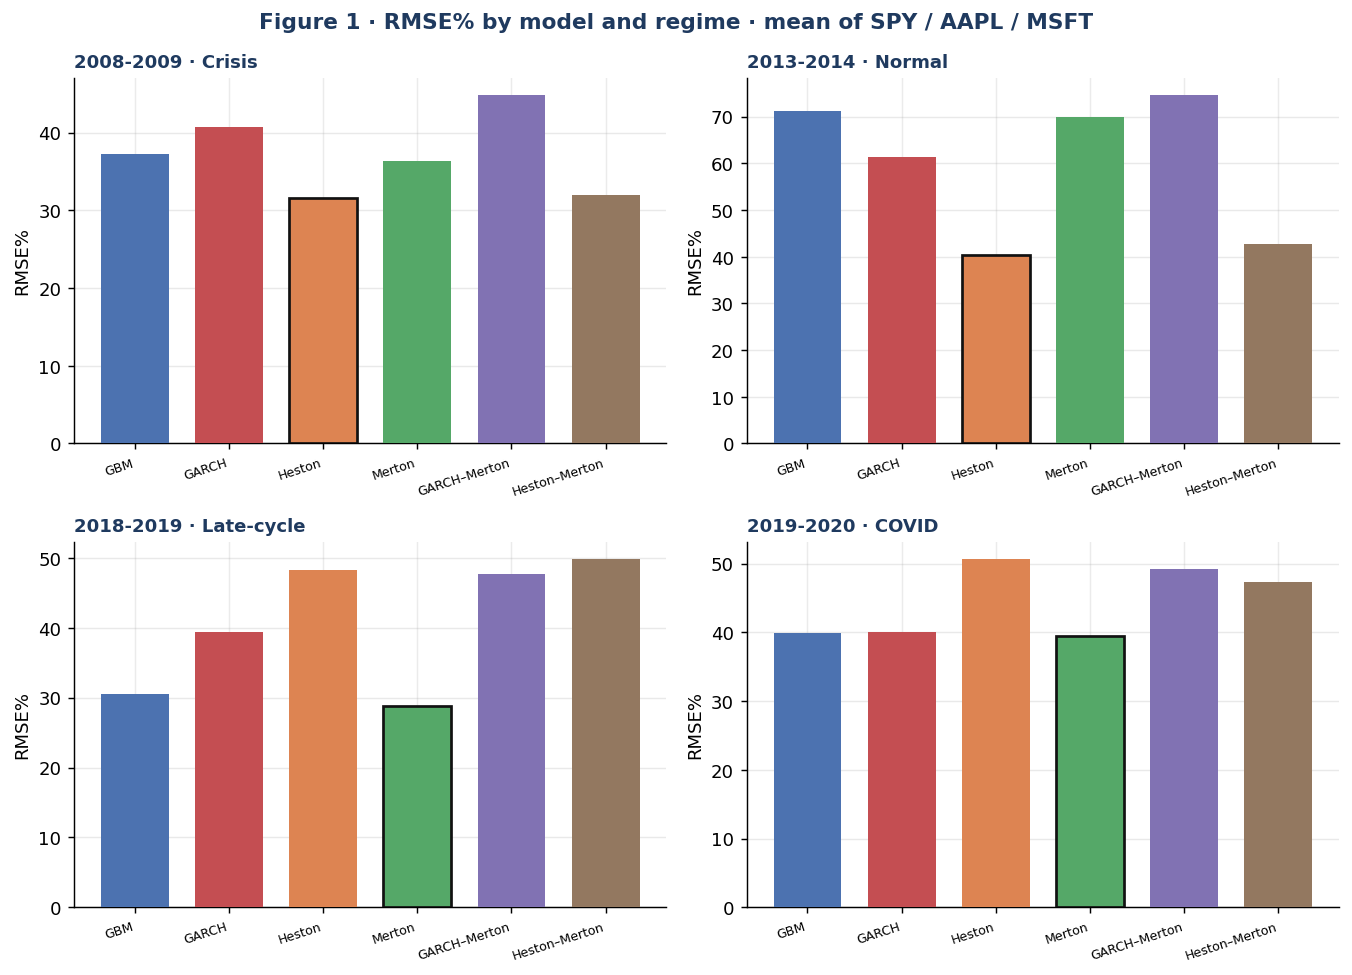

In [1]:
pass  # figure embedded from the same payload used for the PDF

### Figure 2 — RMSE% by company


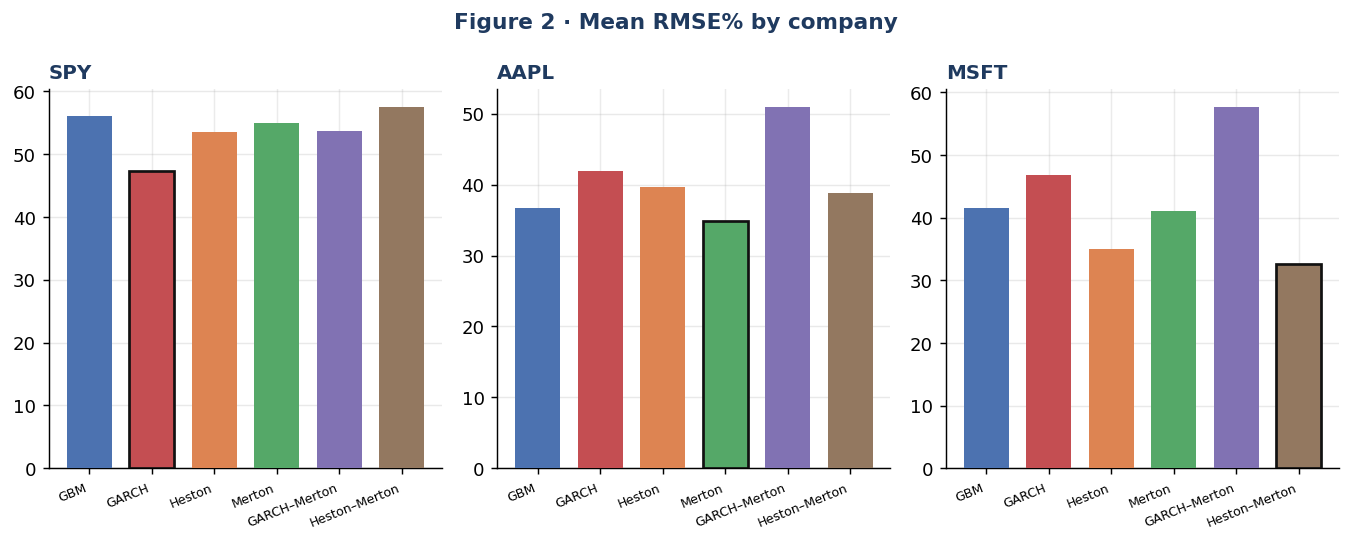

In [1]:
pass

### Figure 3 — Rank heatmap


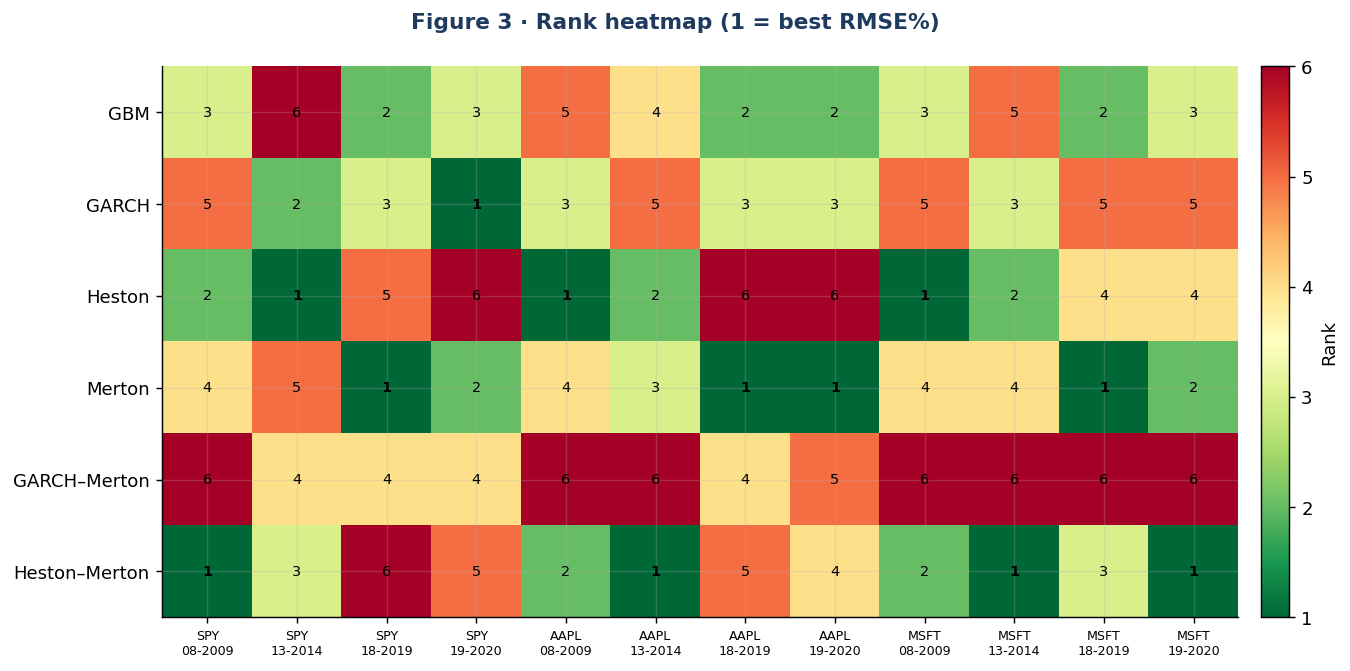

In [1]:
pass

## 5. Final analysis

- On mean percentage RMSE across the 12 company×regime cells, Heston is the best overall model (mean RMSE% = 42.73; 3 of 12 cells).

- Second overall is Heston–Merton (mean RMSE% = 42.97; 4 cells).

- The ranking is not stable. Best-in-cell models across the 12 tables: GARCH, Heston, Heston–Merton, Merton.

- SPY: lowest mean RMSE% is GARCH (47.32); wins 1 of 4 regimes.

- AAPL: lowest mean RMSE% is Merton (34.89); wins 2 of 4 regimes.

- MSFT: lowest mean RMSE% is Heston–Merton (32.68); wins 2 of 4 regimes.

- 2008-2009 (Crisis): best mean RMSE% is Heston (31.55).

- 2013-2014 (Normal): best mean RMSE% is Heston (40.42).

- 2018-2019 (Late-cycle): best mean RMSE% is Merton (28.78).

- 2019-2020 (COVID): best mean RMSE% is Merton (39.50).

- No-jump models as a group have lower mean RMSE% (44.27) than the three jump models (46.90).

- For the overall winner (Heston), crisis RMSE% is 31.55 vs 40.42 in the 2014 normal year — absolute pricing error is regime-dependent even when the ranking is not.

- These conclusions are conditional on the V3 filters, 5-year monthly calibration, Monday ATM sample, LSM with 2,000 paths, and American-call quotes only. They are not a statement about European options or other tenors.


## 6. Reproducibility

```python
RECOMPUTE = True
payload = study.run_or_load(recompute=True)
study.write_pdf(payload)
study.build_notebook(payload)
```

Partial results resume from `V3-Models_result/results/empirical_study_5y_monthly/partial/`.
Shared contracts are frozen in `shared_contracts.json` so a resumed run cannot silently change the sample.
